29
29
I0 = 3.62e-07 +- 1.21e-08
n = 1.02e+00+- 1.05e-02


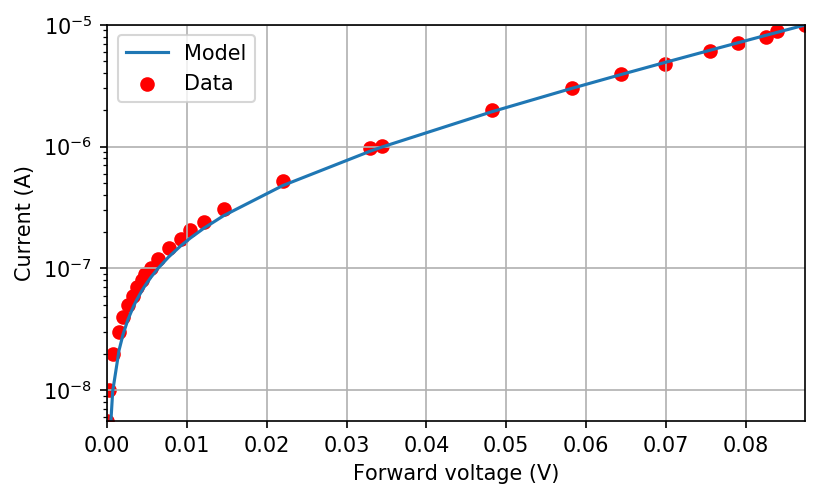

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

def diode_model(v,I_0,n):
    #takes a voltage and returns a current
    q = -1.602e-19 #Coulombs
    k = 1.38e-23 #J.K^-1
    T = 297 #Kelvin
    return I_0*(np.exp(-q*v/(n*k*T))-1)

#voltage = np.array([0,10,20,30,40,50,60,70,80,90,100,
#    120,140,160,180,200,230,260,290,320,350,380,410,
#    440,470,500,530,560,590,620,650,680,710,740,770,800,900,
#    1000,1100,1200,1300,1400,1500,1600,1700,1800])

#current = np.array([14.8e-3,0.327,0.552,0.702,0.811,0.891,0.949,0.995,
#    1.030,1.061,1.083,1.116,1.132,1.165,1.186,1.206,
#    1.236,1.263,1.290,1.316,1.342,1.369,1.400,1.433,1.471,1.519,1.573,
#    1.647,1.736,1.838,1.958,2.091,2.238,2.405,2.588,2.753,3.45,4.20,
#    4.99,5.84,6.74,7.71,8.72,9.82,10.98,12.24])

voltage = np.array([33,22,14.6,12.1,10.4,9.2,
          7.7,6.4,4.8,4.4,3.7,3.3,2.6,2.0,
        1.5, 0.7, 0.2, 5.5, 87.4, 84.0 ,82.5 ,79.0,
           75.6, 69.9, 64.4, 58.2, 48.2, 34.5, 0])

current = np.array([970,520,310,240,208,176,
           147,120,90,80,70,60,50,40,
           30, 20, 10, 100, 10e3, 8.8e3, 8e3, 7.1e3,
           6.1e3,4.8e3,3.92e3,3.05e3,2.0e3,1.01e3, 5.6])

print(len(voltage))
print(len(current))

current = current/1e9
voltage = voltage/1e3

current = np.sort(current)
voltage = np.sort(voltage)

#plt.plot(voltage,current)
#plt.show()
x0 = [1e-7,1]
popt, pcov = curve_fit(diode_model, voltage, current, x0)

print('I0 = {0:.2e} +- {1:.2e}'.format(popt[0],np.sqrt(pcov[0,0])))

print('n = {0:.2e}+- {1:.2e}'.format(popt[1],np.sqrt(pcov[1,1])))

size = 5
fig=plt.figure(figsize=(6, 3.5), dpi= 150)

plt.plot(voltage,diode_model(voltage,popt[0],popt[1]))
plt.scatter(voltage,current,c = 'r')
plt.axis([voltage.min(), voltage.max(), current.min(), current.max()])
plt.yscale('log')
plt.xlabel('Forward voltage (V)')
plt.ylabel('Current (A)')
plt.grid()
plt.legend(['Model','Data'])
plt.show()
fig.savefig('PD_chapter_forward_bias_IV.eps',format='eps')
